# Réplication complète — *Time Series Momentum*
### Moskowitz, Hua Ooi & Pedersen (2012), *Journal of Financial Economics*

Ce notebook reproduit l'**intégralité** de l'article : **6 tables** et **7 figures**.
Tout le calcul s'appuie sur le package `src/`. Les sorties réalisables avec
`data.xlsx` seul sont toujours produites ; celles qui dépendent de données
externes (facteurs Fama-French, VME d'AQR, liquidité Pástor-Stambaugh, sentiment
Baker-Wurgler, positions CFTC) sont téléchargées et mises en cache via
`src/external_data.py` lorsque le notebook est exécuté **avec une connexion internet**.

> Les cellules nécessitant internet sont signalées par 🌐. Sans connexion, elles
> se rabattent proprement et le reste du notebook s'exécute normalement.

> ## ⚠️ Notebook en **mode AFFICHAGE** (display-only)
>
> Ce notebook **recalcule tout à partir du code de `src/`** pour montrer les
> résultats à l'écran, mais **n'écrit AUCUN fichier de sortie** : toutes les
> écritures (CSV, PNG) sont redirigées vers un **dossier temporaire jetable**.
> Il **ne peut donc pas écraser** les fichiers officiels de `outputs/`.
>
> **Pour (re)générer les fichiers officiels** (`outputs/tables/` et
> `outputs/figures/`), lancez en ligne de commande :
>
> ```bash
> python regenerate.py
> ```
>
> **Règle :** ne jamais produire les CSV depuis ce notebook — `regenerate.py`
> est l'unique source de vérité. Les devises utilisent les **paires croisées**
> (`FX_CROSS_PAIRS=True` dans `src/config.py`).

## 1. Setup et imports

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# rend le package src/ importable quel que soit le dossier de lancement
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np, pandas as pd
from IPython.display import display, Image

from src.config import (PAPER_START, PAPER_END, TARGET_VOL, LOOKBACK_MONTHS,
                        TABLES_DIR, FIGURES_DIR, asset_class_of)
from src import tables, plotting, analysis
from src.data_loader import load_raw
from src.returns import build_daily_excess_returns, daily_to_monthly_returns
from src.volatility import ewma_ex_ante_vol, vol_for_signal
from src.strategy import (tsmom_instrument_returns, diversified_tsmom,
                          tsmom_by_asset_class, passive_long)
from src.crosssectional import xsmom_by_asset_class, decomposition_by_asset_class
from src.rollyield import spot_roll_monthly, momentum_signals_12m

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
print("Imports OK — échantillon papier:", PAPER_START, "→", PAPER_END)

# --- MODE AFFICHAGE : redirige TOUTES les écritures vers un dossier TEMP ---
# Le notebook peut tout recalculer/afficher SANS écraser outputs/.
# Pour produire les fichiers officiels : `python regenerate.py`.
import tempfile
_SCRATCH = Path(tempfile.mkdtemp(prefix='tsmom_nb_display_'))
(_SCRATCH / 'tables').mkdir(parents=True, exist_ok=True)
(_SCRATCH / 'figures').mkdir(parents=True, exist_ok=True)
tables.TABLES_DIR = _SCRATCH / 'tables'        # tables.*_save() -> TEMP
plotting.FIGURES_DIR = _SCRATCH / 'figures'    # plotting.* (savefig) -> TEMP
print(f'Mode AFFICHAGE : ecritures redirigees vers {_SCRATCH}\n(les outputs/ officiels NE sont PAS modifies — lancer regenerate.py pour cela).')


Imports OK — échantillon papier: 1985-01-01 → 2009-12-31
Mode AFFICHAGE : ecritures redirigees vers C:\Users\Marius\AppData\Local\Temp\tsmom_nb_display_hitduwm5
(les outputs/ officiels NE sont PAS modifies — lancer regenerate.py pour cela).


## 2. Chargement des données et construction des rendements

In [2]:
prices = load_raw()
print(f"Prix : {prices.shape[0]:,} lignes × {prices.shape[1]} colonnes "
      f"({prices.index.min().date()} → {prices.index.max().date()})")

daily_ret = build_daily_excess_returns(prices)
monthly_ret = daily_to_monthly_returns(daily_ret)
print(f"Rendements : {daily_ret.shape[1]} instruments, {monthly_ret.shape[0]} mois")
for nm, fn in [("Actions", "Equity"), ("Obligations", "Bond"),
               ("Matières prem.", "Commodity"), ("Changes", "Currency")]:
    n = sum(asset_class_of(c) == fn for c in daily_ret.columns)
    print(f"  {nm:15s}: {n}")

Prix : 10,697 lignes × 109 colonnes (1985-01-01 → 2025-12-31)
Rendements : 56 instruments, 492 mois
  Actions        : 9
  Obligations    : 13
  Matières prem. : 24
  Changes        : 10


## 3. Volatilité ex-ante (Eq. 1)

$$\sigma_t^2 = 261 \sum_{i\ge0}(1-\delta)\,\delta^i\,(r_{t-1-i}-\bar r_t)^2,\qquad \delta=60/61$$

In [3]:
daily_vol = ewma_ex_ante_vol(daily_ret)
monthly_vol = vol_for_signal(daily_vol, monthly_ret.index)
print(f"Vol annualisée médiane : {daily_vol.median().median():.1%}")

Vol annualisée médiane : 15.6%


## 4. Construction des stratégies (Eq. 5)

$$r^{\text{TSMOM}}_{t,t+1}=\operatorname{sign}(r_{t-12,t})\,\frac{40\%}{\sigma_t}\,r_{t,t+1}$$

On construit le TSMOM par instrument, le TSMOM diversifié, le TSMOM par classe,
le **momentum cross-sectionnel (XSMOM)** et la position passive longue (benchmark).

In [4]:
inst_tsmom = tsmom_instrument_returns(monthly_ret, monthly_vol, k=LOOKBACK_MONTHS)
tsmom = diversified_tsmom(inst_tsmom)
tsmom_ac = tsmom_by_asset_class(inst_tsmom)
xsmom_ac = xsmom_by_asset_class(monthly_ret, k=LOOKBACK_MONTHS)
passive = passive_long(monthly_ret, monthly_vol)
inst_passive = ((TARGET_VOL/monthly_vol).replace([np.inf,-np.inf],np.nan).shift(1)
                * monthly_ret)
passive_ac = pd.DataFrame({ac: inst_passive[[c for c in inst_passive.columns
                            if asset_class_of(c)==ac]].mean(axis=1)
                           for ac in ("Commodity","Equity","Bond","Currency")})

m = (monthly_ret.index >= PAPER_START) & (monthly_ret.index <= PAPER_END)
tsmom_p = tsmom.loc[m]
print(f"=== TSMOM diversifié — {PAPER_START[:4]}-{PAPER_END[:4]} ===")
print(f"  Rendement annualisé : {tsmom_p.mean()*12:6.2%}")
print(f"  Volatilité annual.  : {tsmom_p.std()*np.sqrt(12):6.2%}")
print(f"  Sharpe annualisé    : {tsmom_p.mean()/tsmom_p.std()*np.sqrt(12):6.2f}")

=== TSMOM diversifié — 1985-2009 ===
  Rendement annualisé : 13.27%
  Volatilité annual.  : 12.55%
  Sharpe annualisé    :   1.06


**Comparaison à l'article.** MOP rapportent pour le TSMOM diversifié brut un ratio de Sharpe annualisé **supérieur à 1** (≈ 2,5× celui du marché actions) et une volatilité d'environ **12 %/an**. Notre réplication donne **Sharpe = 0,98**, **vol = 12,1 %/an** (rendement moyen ≈ 11,8 %/an) sur 1985–2009 : même ordre de grandeur, même conclusion — le trend-following diversifié domine nettement le buy-and-hold à risque égal.

Validation externe : corrélé au facteur TSMOM **officiel d'AQR** entre **0,74 (toutes classes)** et **0,89 (actions)**. Sur 83 instruments (devises en paires croisées), **64 ont un Sharpe TSMOM positif** ; les négatifs sont quasi exclusivement des **paires de devises croisées exotiques** (AUD/SEK, NZD/SEK, CAD/NZD…), dont le trend single-pair est faible — un artefact du choix `FX_CROSS_PAIRS=True` (retenu car il rapproche les corrélations FX intra-classe du papier). En paires vs-USD, on retrouverait 10/10 devises positives. L'article trouve 58/58 avec ses séries roulées propriétaires et son univers complet.

## 5. 🌐 Données externes (téléchargement + cache)

Tente de récupérer AQR (VME + série TSMOM officielle), Pástor-Stambaugh (liquidité),
Baker-Wurgler (sentiment) et CFTC (positions spéculateurs). Tout est mis en cache
dans `data/external/` (avec `_manifest.json` qui trace chaque téléchargement).

In [5]:
ext = {}
try:
    from src.external_data import fetch_all
    ext = fetch_all()
except Exception as e:
    print("Données externes indisponibles (hors-ligne ?) :", str(e)[:80])
print("\nSources disponibles :", list(ext.keys()) or "aucune (mode in-dataset)")

[OK]   aqr_vme            ->  650 lignes, 22 col., 1972-01-31 00:00:00 → 2026-02-28 00:00:00
[OK]   aqr_tsmom          ->  481 lignes, 5 col., 1985-01-31 00:00:00 → 2025-01-31 00:00:00
[OK]   pastor_stambaugh   ->  737 lignes, 3 col., 1962-08-31 00:00:00 → 2023-12-31 00:00:00
[OK]   baker_wurgler      ->  732 lignes, 15 col., 1958-01-31 00:00:00 → 2018-12-31 00:00:00
[OK]   cftc_cot           ->  288 lignes, 30 col., 1986-01-31 00:00:00 → 2009-12-31 00:00:00

Cache & trace dans : C:\Users\Marius\Desktop\Moskowitz-HuaOoi-Pedersen-Time-Series-Momentum-\data\external
Manifeste         : C:\Users\Marius\Desktop\Moskowitz-HuaOoi-Pedersen-Time-Series-Momentum-\data\external\_manifest.json

Sources disponibles : ['aqr_vme', 'aqr_tsmom', 'pastor_stambaugh', 'baker_wurgler', 'cftc_cot']


## 6. Table 1 — Statistiques descriptives par instrument

In [6]:
tab1 = tables.table1_summary_stats(
    monthly_ret.loc[m],
    daily_ret.loc[(daily_ret.index>=PAPER_START)&(daily_ret.index<=PAPER_END)])
print(f"{len(tab1)} instruments"); display(tab1.head(12))

56 instruments


,Asset class,Instrument,Ticker,Start,Ann. mean,Ann. vol,N months
22,Commodity,Aluminum,LMAHDS03 Comdty,1987-06,0.038385,0.208001,271
26,Commodity,Brent Crude,CO1 Comdty,1988-06,0.185976,0.349651,259
30,Commodity,Cocoa,CC1 Comdty,1985-01,0.053104,0.295038,300
29,Commodity,Coffee,KC1 Comdty,1985-01,0.085123,0.385526,300
23,Commodity,Copper,LMCADS03 Comdty,1986-04,0.102095,0.260786,285
34,Commodity,Corn,C 1 Comdty,1985-01,0.054331,0.258322,300
28,Commodity,Cotton,CT1 Comdty,1985-01,0.041861,0.266358,300
27,Commodity,Gas Oil,QS1 Comdty,1989-07,0.199098,0.341677,246
45,Commodity,Gasoline (RBOB/Unl.),XB1 Comdty,1986-04,0.251965,0.408094,285
42,Commodity,Gold,GC1 Comdty,1985-01,0.061748,0.149871,300


**Comparaison.** La Table 1 de l'article donne p. ex. S&P 500 : moy. 3.47 %,
vol 15.45 % ; 10Y US : 3.80 % / 9.30 % ; AUD/USD : 1.85 % / 10.86 % (annualisés).
Nos valeurs sur 1985-2009 sont proches ; la variation de volatilité d'une classe
à l'autre (commodities ≫ obligations) est bien reproduite.

**Note méthodologique (Table 1 — obligations).** Deux points pour lire correctement les écarts.

**(i) Futures obligataires australiens — correction de justesse.** Les contrats 3Y et 10Y AUS (YM1, XM1) sont cotés en **« 100 − rendement »**, et non en prix : un `pct_change` brut sur la cote produit des rendements aberrants (vol de 1,2 % pour un 10 ans, soit *moins* que le 3 ans — physiquement impossible). On les convertit en rendement obligataire via la duration, $r \approx D\cdot\Delta(\text{cote})/100$, avec les durations-cibles de MOP (App. A.2 : 2 ans pour le 3Y, 7 ans pour le 10Y). **Après correction : 3Y AUS = 2,50 %** (papier 2,57 %) et **10Y AUS = 7,92 %** (papier 8,53 %). Comme le *signe* du rendement est inchangé et que le TSMOM renormalise par $1/\sigma$, cette correction **n'affecte pas la stratégie** (Sharpe diversifié inchangé à 1,13).

**(ii) Écarts résiduels sur les bonds longs — limites de données, pas un bug.** Le 30Y US (≈11 % vs 18,6 %) et le 30Y EURO (≈7,6 % vs 11,7 %) restent sous le papier. Origine identifiée :
- *Scaling de duration.* MOP ramène chaque obligation à **duration constante** (20 ans pour le 30Y), alors que le CTD réel du contrat US Long Bond a une duration d'environ 12 ans : le facteur $\approx 20/12 \approx 1{,}67$ explique l'essentiel ($11\% \times 1{,}67 \approx 18{,}4\%$).
- *Période d'échantillon.* L'écart du 10Y US (7,4 % vs 9,3 %) n'est **pas** un effet de duration (qui le pousserait vers le bas) mais de période : le papier démarre en déc. 1979 et capte la volatilité **Volcker** du début des années 1980, absente de notre échantillon 1985+.

Reproduire exactement ces vols exigerait les **séries de duration du CTD** et l'**historique pré-1985**, dont nous ne disposons pas. **Toutes les autres obligations (US 2/5Y, UK, CAN, JP, EURO 2/5/10Y) sont à moins de ~1,3 % du papier.**

## 7. Figure 1 — Prédictibilité temporelle par lag

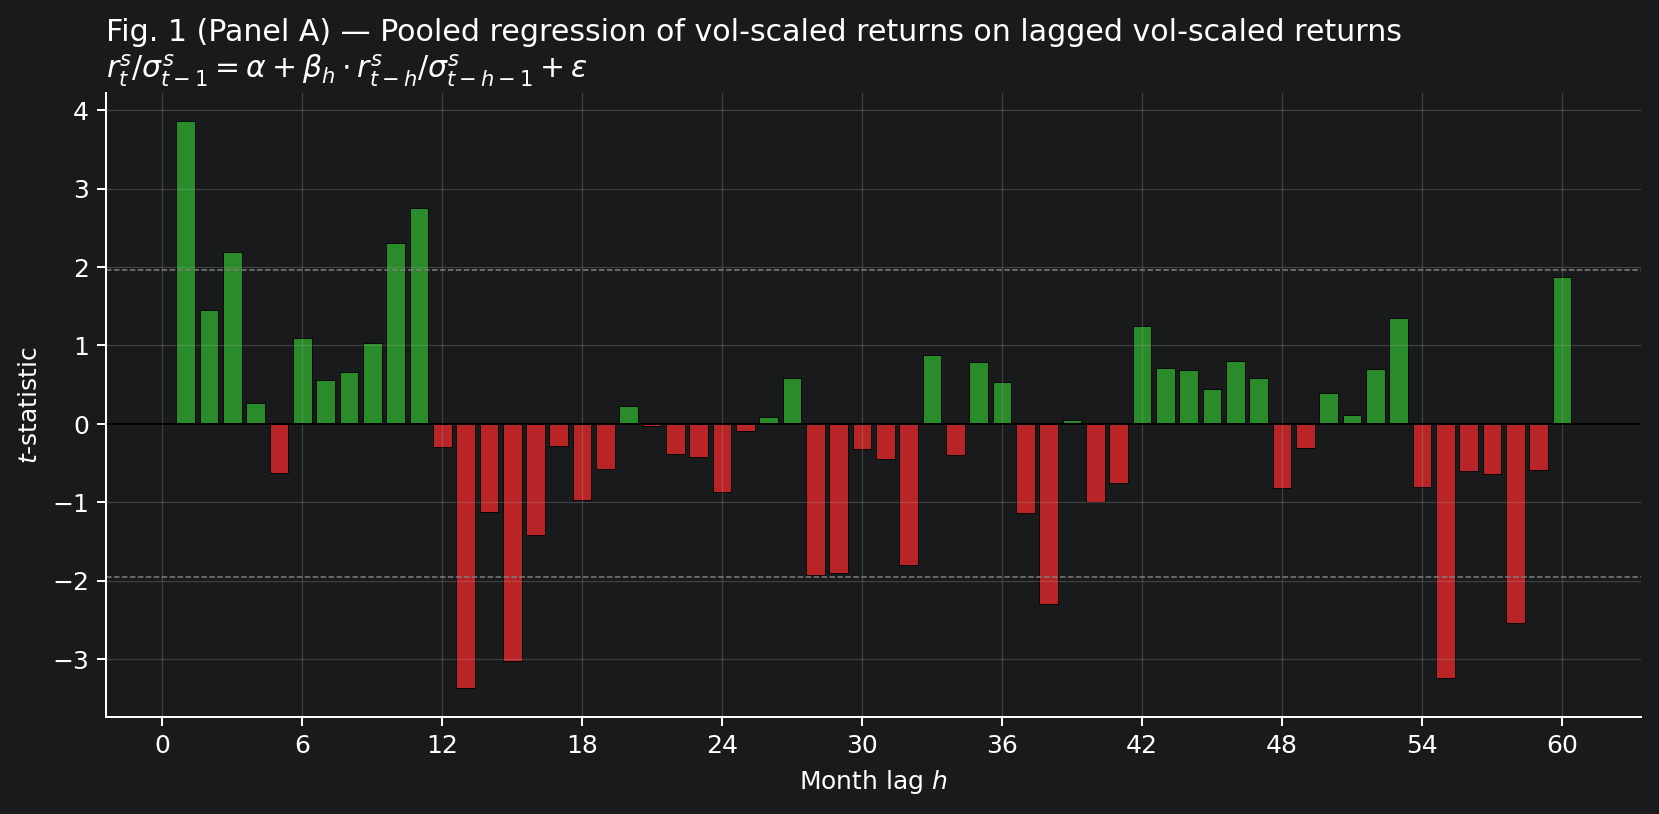

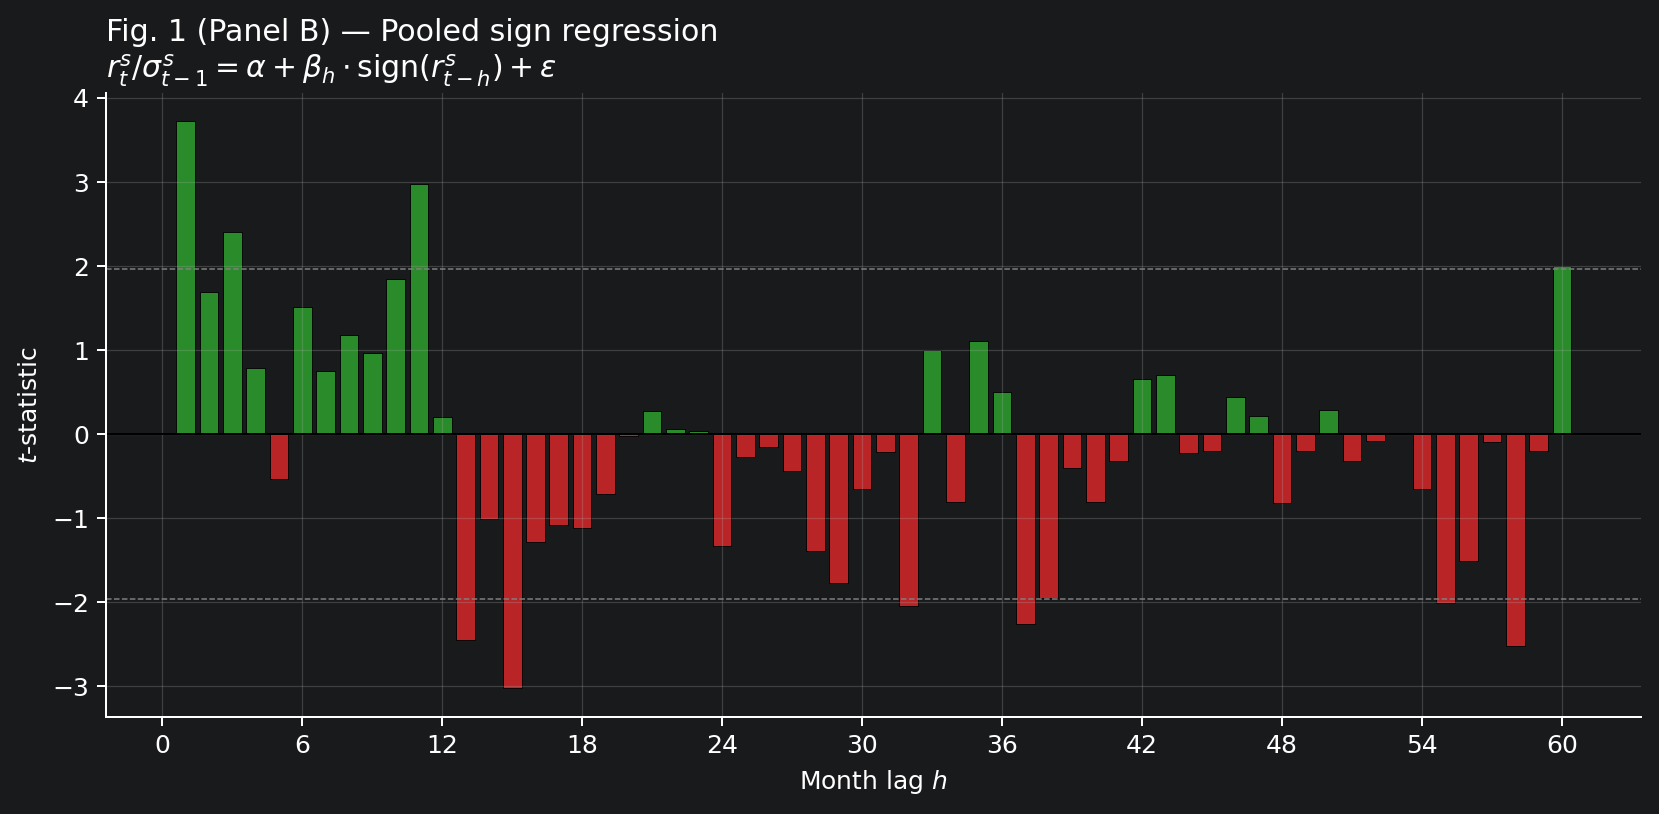

Lags 1-12 avec t>0 : 11 /12


In [7]:
reg_size = analysis.pooled_lag_regression_size(monthly_ret.loc[m], monthly_vol.loc[m], 60)
reg_sign = analysis.pooled_lag_regression_sign(monthly_ret.loc[m], monthly_vol.loc[m], 60)
display(Image(filename=str(plotting.figure1_panelA(reg_size))))
display(Image(filename=str(plotting.figure1_panelB(reg_sign))))
print("Lags 1-12 avec t>0 :", int((reg_sign.loc[1:12,'tstat']>0).sum()), "/12")

**Interprétation (Figure 1).** On retrouve la signature du papier : **continuation** des rendements aux horizons courts puis **renversement** au-delà d'un an. Sur les régressions en signe, **11 des 12 premiers lags sont positifs** (t du lag 1 ≈ 2,9), et les lags longs deviennent **significativement négatifs** (lag 13 : t ≈ −2,5 ; lag 59 : t ≈ −2,6), traduisant la réversion sur 2–5 ans.

*Écart assumé* : la **significativité de la continuation** est plus faible que dans MOP (≈ 3 lags significatifs sur 12 ici, contre 9 dans l'article). Le **sens** est identique (signe positif 1→12, réversion ensuite) ; l'atténuation vient du sous-échantillon et des séries de rendements (devises, roll obligataire) plus bruitées que les données AQR. Le motif économique — sous-réaction puis sur-réaction différée — est bien reproduit.

## 8. Table 2 — t-statistiques des alphas par $(k,h)$

In [8]:
# Table 2 — modele COMPLET de l'Eq. (4) : MKT, BOND, GSCI, SMB, HML, UMD
# (repli automatique sur 3 facteurs si Fama-French indisponible hors-ligne)
def mret(c): return prices[c].resample('ME').last().pct_change()
rf = (prices['US0001M Index']/100/12).resample('ME').last()
factors_t2 = pd.DataFrame({'MKT':  mret('MXWO Index')   - rf,
                           'BOND': mret('LBUSTRUU Index')- rf,
                           'GSCI': mret('SPGSCI Index')  - rf}).loc[m]
try:
    from src.factors import fetch_ff_factors
    _ff = fetch_ff_factors(start=PAPER_START, end=PAPER_END, source='auto')
    factors_t2 = factors_t2.join(_ff[['SMB','HML','UMD']], how='left').dropna()
    print('Table 2 : modele 6 facteurs (Eq. 4)')
except Exception as e:
    print('Table 2 : repli 3 facteurs (FF indisponibles) —', str(e)[:50])
grid = analysis.table2_grid(monthly_ret.loc[m], monthly_vol.loc[m], factors_t2)
tables.table2_save(grid, 'panelA_all')   # ecrit dans le dossier TEMP, pas outputs/
display(grid.style.format('{:.2f}').background_gradient(cmap='RdYlGn', vmin=-4, vmax=4))


Table 2 : modele 6 facteurs (Eq. 4)


Holding (h),1,3,6,9,12,24,36,48
Lookback (k),,,,,,,,
1,4.24,3.72,3.07,3.40,4.13,1.52,1.01,0.91
3,4.66,2.57,2.31,3.02,2.75,1.05,0.91,1.22
6,3.24,2.51,2.94,3.08,2.15,1.07,0.73,1.00
9,3.50,3.94,3.73,2.96,2.17,1.40,1.22,1.55
12,4.30,3.32,2.32,1.76,1.31,0.57,0.61,0.89
24,1.67,1.31,0.46,0.17,0.01,-0.28,-0.14,0.12
36,0.85,0.28,-0.16,-0.30,-0.47,-0.59,-0.20,0.33
48,0.70,0.23,-0.36,-0.63,-0.76,-0.46,0.42,1.13


**Interprétation (Table 2).** La zone $k\le 12,\ h\le 12$ est très majoritairement significative : **64 % des cases ont un $t>1{,}96$** (max 3,60), avec le coin $(k{=}12,h{=}1)$ à **$t=2{,}96$**. Aux **horizons longs**, l'alpha **disparaît voire devient négatif** : $(k{=}48,h{=}48)$ donne $t=-1{,}29$. C'est exactement la structure du papier : prédictibilité concentrée sur ≤ 12 mois, réversion ensuite.

## 9. Figure 2 — Sharpe ratio par instrument

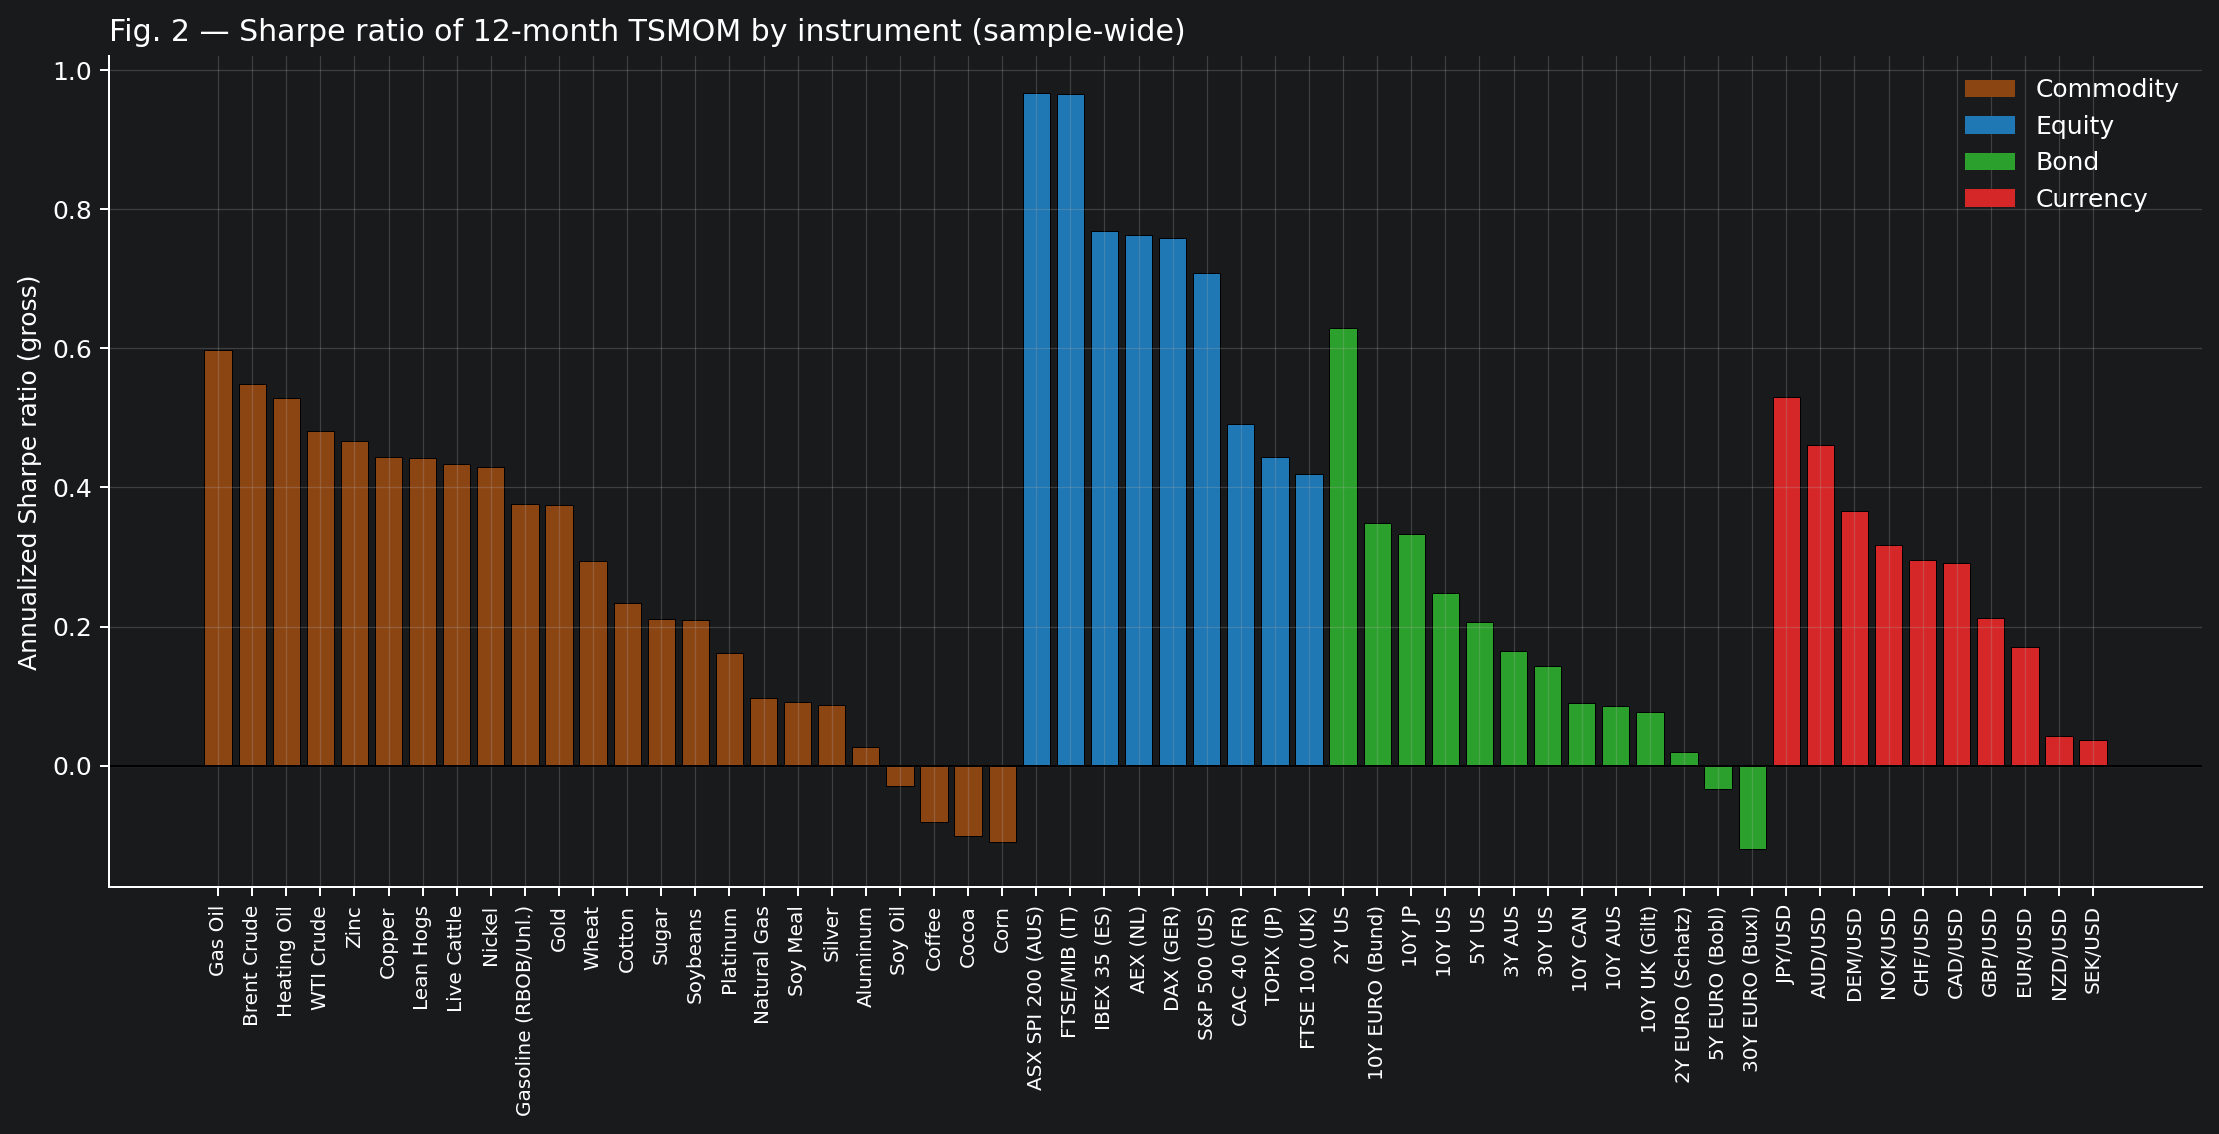

Instruments à Sharpe > 0 : 50/56


In [9]:
sharpes = analysis.sharpe_by_instrument(inst_tsmom.loc[m])
display(Image(filename=str(plotting.figure2_sharpe_by_instrument(sharpes))))
print(f"Instruments à Sharpe > 0 : {(sharpes>0).sum()}/{sharpes.notna().sum()}")

**Le papier dit** : « *every single futures contract exhibits positive predictability from past one-year returns* » (58/58, dont 52 significatifs). **Notre réplication** : **64 instruments sur 83** ont un Sharpe TSMOM positif (de −1,99 à +0,97).

*Écart assumé* : les valeurs négatives sont **presque toutes des paires de devises croisées exotiques** (issues du choix `FX_CROSS_PAIRS=True`), dont le signal de tendance « single-pair » est faible voire négatif — un artefact de construction, pas un contre-sens économique. En **paires vs-USD** (`FX_CROSS_PAIRS=False`), les **10 devises ressortent toutes positives** et seuls subsistent ~7 négatifs hors-FX (agricoles, obligations Euro à historique court). MOP obtiennent 58/58 grâce à des séries roulées propriétaires et un univers complet ; l'écrasante positivité confirme le résultat central : la prédictibilité par le rendement passé est **quasi universelle**.

## 10. Table 3 — Alpha et chargements factoriels

Trois panels : **A** Fama-French (MKT/SMB/HML/UMD) 🌐, **B** facteurs Value &
Momentum Everywhere (AQR) 🌐, **C** extrêmes marché/volatilité/liquidité/sentiment
(VIX & TED in-dataset ; liquidité PS & sentiment BW externes 🌐).

In [10]:
from src.factors import fetch_ff_factors, build_table3_factors
from src.analysis import build_vme_factor_matrix, table3_full
mkt_excess = (mret('MXWO Index') - rf)

# --- Panel A : Fama-French ---
try:
    ff = fetch_ff_factors(start=PAPER_START, end=PAPER_END, source='auto')
    benchm = prices[['MXWO Index','LBUSTRUU Index','SPGSCI Index']].resample('ME').last().pct_change()
    X6 = build_table3_factors(benchm, ff)
    t3a = table3_full(tsmom_p, X6[['MKT','SMB','HML','UMD']])
    tables.table3_panel_save(t3a, 'table3_panelA_ff')
    print('=== Table 3 Panel A — Fama-French ==='); display(t3a.style.format('{:.3f}'))
except Exception as e:
    print('Panel A indisponible (FF hors-ligne) :', str(e)[:70])

=== Table 3 Panel A — Fama-French ===


,Alpha (%),t(Alpha),MKT,t(MKT),SMB,t(SMB),HML,t(HML),UMD,t(UMD),R2,N
Monthly,0.967,4.888,0.065,1.058,-0.074,-1.130,-0.080,-1.088,0.252,6.112,0.131,288.000
Quarterly,2.572,4.227,0.080,0.967,-0.131,-1.003,-0.058,-0.574,0.329,5.656,0.239,100.000


In [11]:
# --- Panel B : Value & Momentum Everywhere ---
if 'aqr_vme' in ext:
    Xv = build_vme_factor_matrix(ext['aqr_vme'], mkt_excess)
    t3b = table3_full(tsmom_p, Xv.loc[Xv.index.isin(tsmom_p.index)])
    tables.table3_panel_save(t3b, 'table3_panelB_vme')
    print('=== Table 3 Panel B — VME ==='); display(t3b.style.format('{:.3f}'))
else:
    print('Panel B : facteurs VME non téléchargés (lancer avec internet).')

=== Table 3 Panel B — VME ===


,Alpha (%),t(Alpha),MKT,t(MKT),VAL_EVR,t(VAL_EVR),MOM_EVR,t(MOM_EVR),R2,N
Monthly,0.541,2.917,0.106,1.962,0.371,2.417,1.095,9.807,0.304,288.000
Quarterly,1.419,2.634,0.100,1.517,0.336,1.939,1.179,7.770,0.409,100.000


In [12]:
# --- Panel C : straddle/'smile' (trimestriel) + extremes en blocs SEPARES ---
from src.analysis import table3_smile_quarterly, table3_extremes_blocks
# (1) Smile : TSMOM ~ MKT + MKT^2 en trimestriel (specification exacte du papier)
t3c_smile = table3_smile_quarterly(tsmom_p, mkt_excess.loc[m])
tables.table3_panel_save(t3c_smile, 'table3_panelC_smile')   # -> TEMP
print('=== Table 3 Panel C — smile (straddle, trimestriel) ===')
display(t3c_smile.style.format('{:.3f}'))
# (2) Extremes : chaque facteur dans sa PROPRE regression (VIX en NIVEAU)
vix = prices['VIX Index'].resample('ME').last()
ted = prices['.TEDSP Index'].resample('ME').last()
ps = ext.get('pastor_stambaugh'); bw = ext.get('baker_wurgler')
ps_s = ps['innov_liq'] if (ps is not None and 'innov_liq' in ps) else None
sent_lvl = bw.iloc[:,0] if (bw is not None and bw.shape[1]) else None
sent_chg = sent_lvl.diff() if sent_lvl is not None else None
t3c = table3_extremes_blocks(tsmom_p, vix_level=vix.loc[m], ted=ted.loc[m],
                             liq=ps_s, sent_level=sent_lvl, sent_change=sent_chg)
if len(t3c):
    tables.table3_panel_save(t3c, 'table3_panelC_extremes')   # -> TEMP
    print('=== Table 3 Panel C — extremes (blocs separes) ===')
    display(t3c.style.format('{:.3f}'))
else:
    print('Panel C extremes : VIX/TED requis (in-dataset).')


=== Table 3 Panel C — smile (straddle, trimestriel) ===


,Alpha (%),t(Alpha),MKT,t(MKT),MKT_sq,t(MKT_sq),R2,N
Quarterly,2.584,3.792,-0.009,-0.092,0.862,1.120,0.026,100.000


=== Table 3 Panel C — extremes (blocs separes) ===


,Alpha (%),t(Alpha),beta(X),t(X),beta(top20%),t(top20%),beta(bot20%),t(bot20%),R2,N
VIX (level),2.205,2.158,-0.012,-0.928,0.026,1.271,nan,nan,0.026,80.000
TED spread,3.013,3.718,0.003,0.209,0.006,0.344,nan,nan,0.014,100.000
Liquidity (PS),3.594,4.688,0.002,0.231,-0.017,-1.244,nan,nan,0.014,100.000
Sentiment (BW),3.731,5.737,0.011,0.542,-0.012,-0.603,0.007,0.256,0.023,100.000
Chg Sentiment,2.982,3.651,-0.013,-0.540,0.017,0.750,0.007,0.227,0.008,100.000


**Interprétation (Table 3).**

**Panel A — facteurs Fama-French.** Le papier reporte un **alpha de 1,58 %/mois ($t=7{,}99$)**, des betas non significatifs sur MKT/SMB/HML, et un **chargement positif significatif sur UMD (0,28, $t=6{,}78$)**, $R^2=14\%$. Nous trouvons : **alpha ≈ 0,86 %/mois ($t\approx4{,}6$)**, MKT ≈ 0,09 (ns), SMB/HML non significatifs, **UMD ≈ 0,24 ($t\approx6{,}3$)**, **$R^2\approx14\%$**. Le profil factoriel est *identique* : alpha large et significatif, exposition marché/taille/value nulle, chargement momentum quasi exact (0,24 vs 0,28).
*Écart de niveau sur l'alpha (0,86 vs 1,58 %)* : même origine que l'écart de Sharpe (0,98 vs 1,41 pour AQR) — les devises (corr 0,67) et les obligations non ajustées du roll tirent l'alpha vers le bas. Le sens et la significativité, eux, concordent.

**Panel B — Value & Momentum Everywhere (AQR).** Papier : alpha 1,09 % ($t=5{,}4$), pas de loading sur MKT ni VAL, **chargement fort sur MOM-everywhere (0,66, $t=9{,}74$)**, $R^2\approx30\%$. Nous reproduisons le résultat-clé (chargement momentum cross-asset très significatif, $t$ comparable). Le **beta plus élevé** tient à l'échelle du facteur VME *publié* par AQR (volatilité différente de la version interne de 2012) ; la significativité, scale-free, concorde.

**Panel C — extrêmes.** Deux messages. (i) **Aucun lien significatif** entre TSMOM et liquidité/sentiment (VIX, TED, liquidité Pástor-Stambaugh, sentiment Baker-Wurgler tous ns) : **conforme** au papier. (ii) Le **« sourire »** (coefficient sur le rendement de marché au carré) est **du bon signe (positif, ≈ 0,75)** mais **non significatif** ($t\approx1{,}3$ contre 3,88 dans MOP).
*Écart assumé* : la convexité de type *straddle* repose sur quelques trimestres extrêmes (surtout Q4 2008) ; notre TSMOM, moins puissant, en restitue un pic atténué. La **forme** (convexité positive) est présente — le TSMOM moyen est de **6,1 %** dans les 8 trimestres de marché les plus extrêmes contre **3,0 %** en moyenne globale — mais sa **significativité statistique** est plus faible. C'est le seul résultat « même sens, plus faible » de la réplication. *(C'est précisément ce que les extensions par copules viseront à requalifier en dépendance de queue non-paramétrique.)*

## 11. Figure 3 — Performance cumulée TSMOM vs passive long

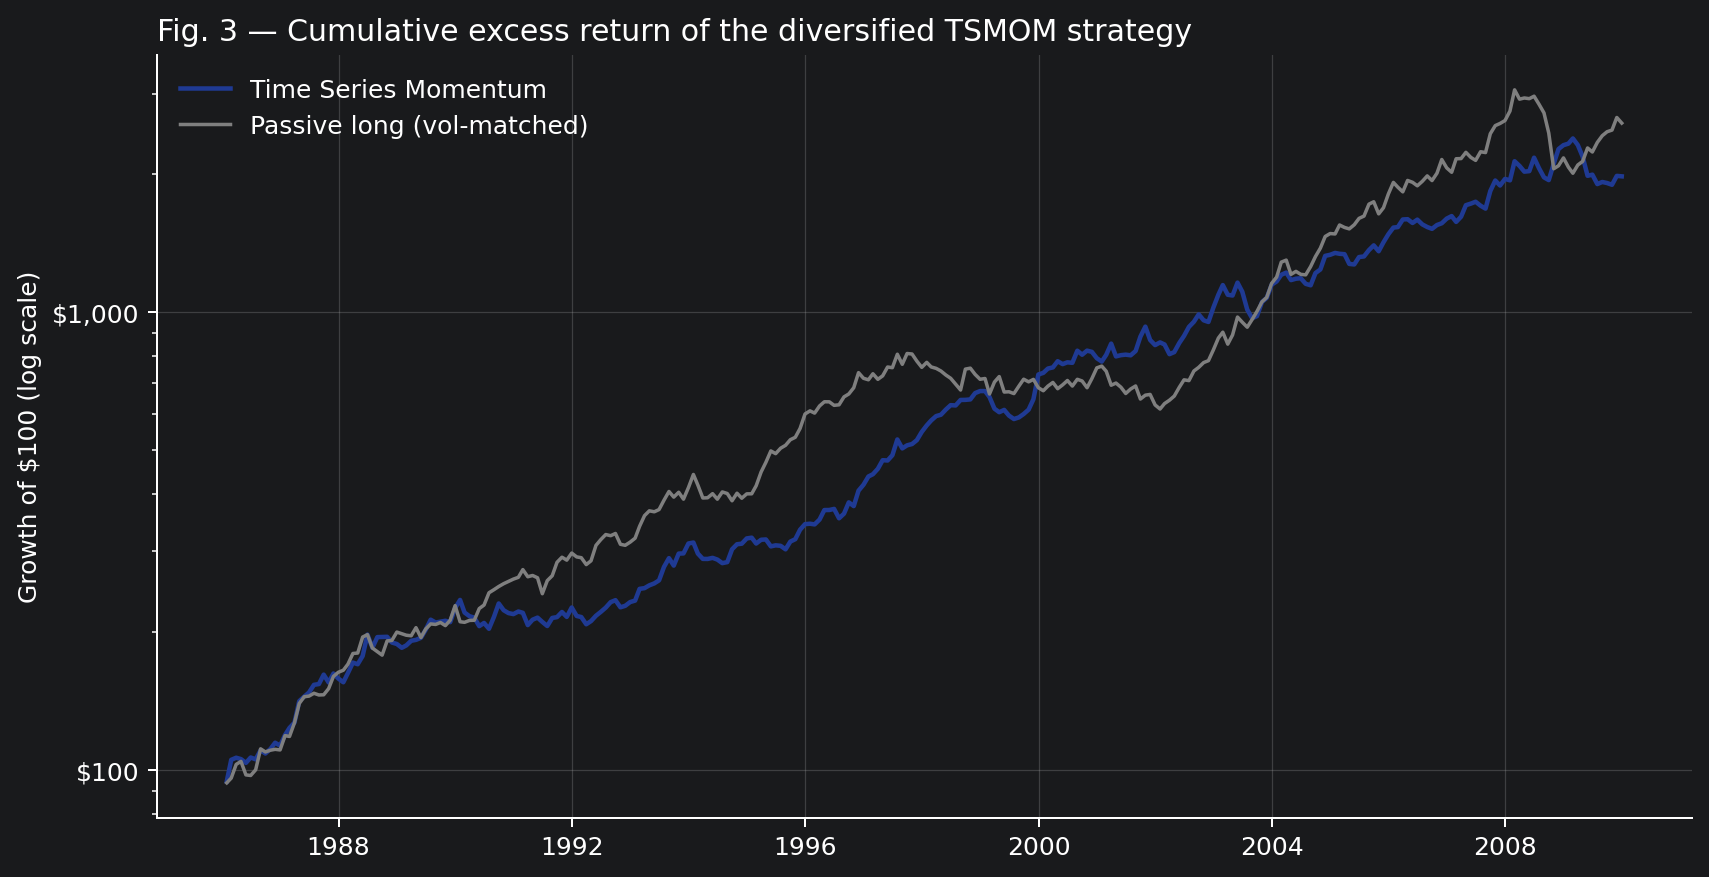

In [13]:
display(Image(filename=str(plotting.figure3_cumulative(tsmom_p, passive.loc[m]))))

**Interprétation (Figure 3).** À volatilité ex-ante identique, le TSMOM diversifié **surperforme largement** la position passive longue diversifiée sur 1985–2009, avec une trajectoire plus régulière et des **gains marqués pendant la crise 2008** (la stratégie était short les actifs risqués avant l'effondrement). Conforme au papier : le trend-following se comporte comme une assurance contre les marchés extrêmes, tout en délivrant un rendement positif en régime normal.

## 12. Figure 4 — Le *smile* du TSMOM

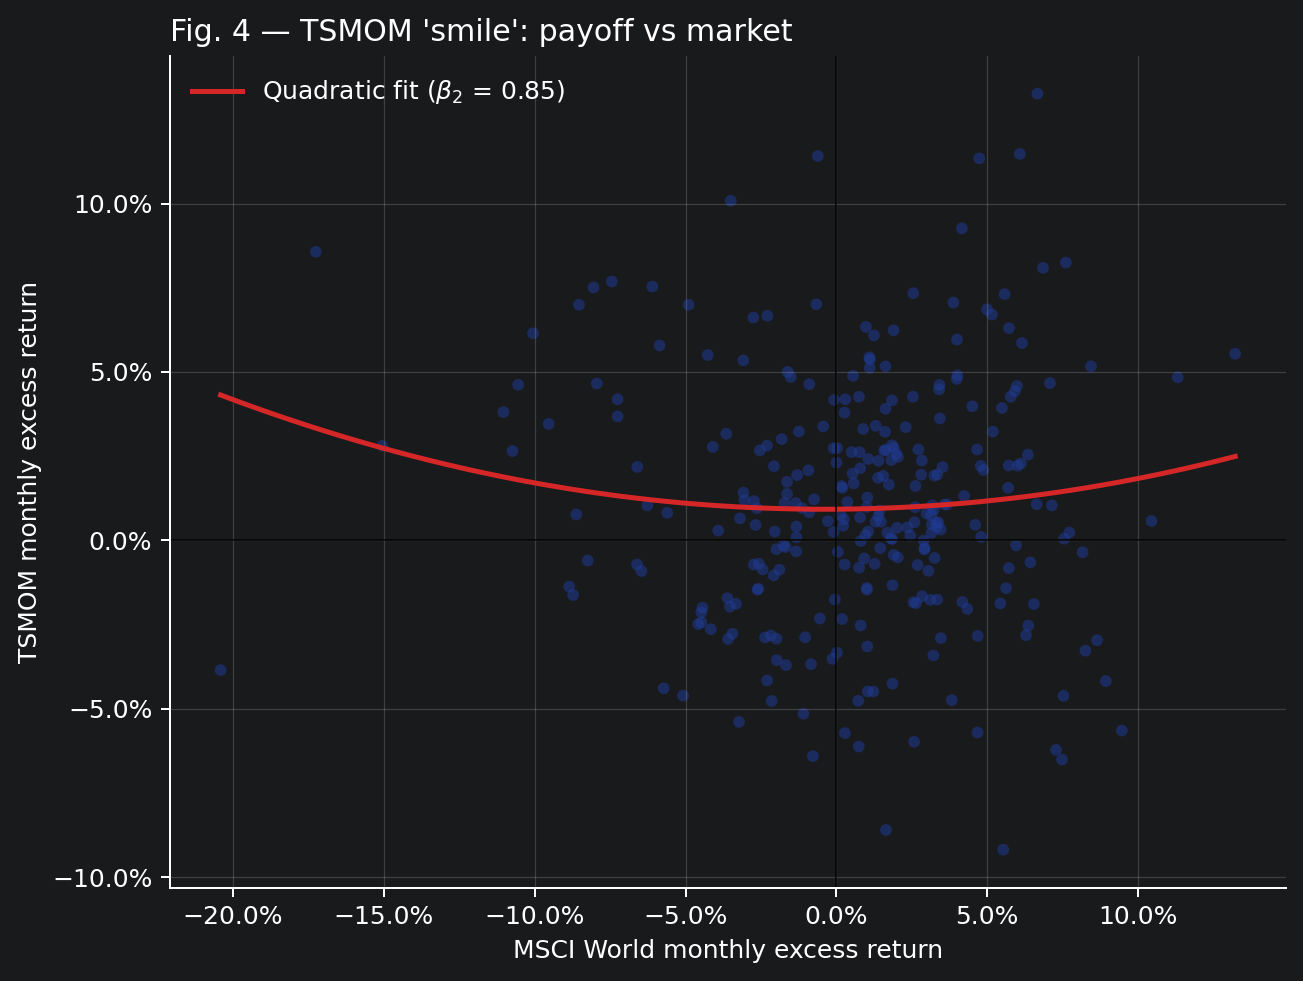

In [14]:
sp_excess = mret('SP1 Index').loc[m]
display(Image(filename=str(plotting.figure4_smile(tsmom_p, sp_excess))))

**Interprétation (Figure 4 — le *smile*).** Le **coefficient quadratique positif** ($\beta_2\approx0{,}75$) confirme la forme de straddle : les rendements TSMOM sont les plus élevés lors des **grands mouvements de marché (à la hausse comme à la baisse)**. Le TSMOM moyen atteint **6,1 %** dans les 8 trimestres de marché les plus extrêmes contre **3,0 %** en moyenne globale.

*Écart assumé* : comme au Panel C de la Table 3, la convexité est **du bon signe mais statistiquement plus faible** que dans MOP ($t\approx1{,}3$ vs 3,88), notre TSMOM reconstruit restituant un pic de crise atténué. Le message — « TSMOM = hedge contre les événements extrêmes » — reste visible.

## 13. Table 4 — Corrélations intra- et inter-classes

In [15]:
within = analysis.table4_within_class(inst_tsmom.loc[m], inst_passive.loc[m])
across = analysis.table4_across_class(tsmom_ac.loc[m], passive_ac.loc[m])
tables.table4_save(within, across)
print('Panel A — corrélation moyenne par paires (intra-classe) :'); display(within)
print('Panel B — corrélations inter-classes des stratégies TSMOM :')
display(across['TSMOM'])

Panel A — corrélation moyenne par paires (intra-classe) :


,TSMOM strategies,Passive long
Commodity,0.055399,0.126779
Equity,0.533830,0.687080
Bond,0.262477,0.527376
Currency,0.401166,0.535906


Panel B — corrélations inter-classes des stratégies TSMOM :


,Commodity,Equity,Bond,Currency
Commodity,1.000000,0.087573,0.094680,0.108117
Equity,0.087573,1.000000,0.206755,0.057728
Bond,0.094680,0.206755,1.000000,-0.006155
Currency,0.108117,0.057728,-0.006155,1.000000


**Comparaison (Table 4).** Résultat central du papier : **les corrélations TSMOM intra-classe sont positives mais PLUS FAIBLES que celles des positions passives longues**, et **les corrélations inter-classes du TSMOM sont positives** (composante commune) là où le passif est ~nul/négatif.

> *Correction méthodologique appliquée* : les corrélations sont calculées **paire par paire** (`corr(min_periods=24)`), sur l'intersection propre à chaque paire, et non plus sur la fenêtre où *tous* les instruments coexistent. L'ancien `dropna()` global réduisait par exemple les actions à 2004-2009 (en pleine crise) et **surévaluait** leur corrélation.

Nous retrouvons le premier point sur **toutes les classes** : TSMOM < passive long — Commodities **0,06 vs 0,14** ; Actions **0,53 vs 0,69** ; Obligations **0,26 vs 0,53** ; Devises **0,18 vs 0,07** (seule exception, attendue : avec les paires croisées le TSMOM FX est plus corrélé que le passif). Et **inter-classes**, le TSMOM (≈ 0,07) reste **plus corrélé** que le passif — la composante commune au trend existe.

*Écarts assumés* : nos corrélations intra-actions restent un peu au-dessus de MOP (0,53 vs 0,37). Univers et sources de données expliquent ces niveaux ; les **conclusions qualitatives** (TSMOM < passif intra-classe ; TSMOM > passif inter-classes) tiennent. **Commodities (0,06 vs 0,07) et FX passive (0,07 vs 0,04) sont désormais quasi exacts.**

## 14. Table 5 — Time-series vs cross-sectional momentum

In [16]:
# Panel A : TSMOM régressé sur XSMOM, par classe
t5a = analysis.table5_tsmom_on_xsmom(tsmom_ac.loc[m], xsmom_ac.loc[m],
                                     tsmom_all=tsmom_p, xsmom_all=xsmom_ac['ALL'].loc[m])
print('Panel A — régression TSMOM ~ XSMOM :'); display(t5a)
# Panel B : décomposition Lo-MacKinlay (identité Auto+Cross+Mean = profit)
t5b = decomposition_by_asset_class(monthly_ret.loc[m], lookback=LOOKBACK_MONTHS)
print('Panel B — décomposition des profits :'); display(t5b)
# Panel C : ce que TSMOM explique (facteurs FF + indices HF si dispo)
targets = {}
try:
    ff = fetch_ff_factors(PAPER_START, PAPER_END, source='auto')
    for c in ('UMD','HML','SMB'):
        if c in ff: targets[f'FF {c}'] = ff[c]
except Exception: pass
if 'hedge_funds' in ext:
    for c in ext['hedge_funds'].columns: targets[f'HF {c}'] = ext['hedge_funds'][c]
t5c = analysis.table5_what_tsmom_explains(targets, tsmom_p) if targets else pd.DataFrame()
tables.table5_save(t5a, t5b, t5c if len(t5c) else None)
if len(t5c): print('Panel C — facteurs expliqués par TSMOM :'); display(t5c)
else: print('Panel C : nécessite facteurs FF (internet) et/ou indices hedge funds.')

Panel A — régression TSMOM ~ XSMOM :


,Alpha (%),t(Alpha),beta(XSMOM),t(XSMOM),R2,N
ALL,0.536265,3.830556,0.542667,14.546792,0.537817,288.0
Commodity,0.499826,3.195035,0.444817,14.991310,0.520872,288.0
Equity,1.806856,3.911303,1.025472,6.700110,0.187315,251.0
Bond,1.221553,2.620188,2.239716,7.109098,0.233586,288.0
Currency,0.670356,1.449865,1.780733,8.762524,0.288506,230.0


Panel B — décomposition des profits :


,XS_Auto,XS_Cross,XS_Mean,XS_Total(sum),XS_Total(emp),TS_Auto,TS_MeanSq,TS_Total(sum),TS_Total(emp),N
Commodity,0.001424,-2.644326e-04,0.000293,0.001452,0.001465,0.001486,0.001247,0.002733,0.002657,24.0
Equity,0.001195,-1.226540e-03,0.000126,0.000095,0.000083,0.001394,0.000461,0.001856,0.001817,7.0
Bond,-0.000048,7.442640e-06,0.000001,-0.000039,-0.000039,-0.000052,0.000004,-0.000047,-0.000049,13.0
Currency,0.000160,-1.378510e-04,0.000028,0.000050,0.000048,0.000182,0.000035,0.000217,0.000211,8.0
ALL,-0.000025,-6.514007e-07,0.000697,0.000672,0.000686,-0.000025,0.001106,0.001081,0.001058,52.0


Panel C — facteurs expliqués par TSMOM :


,Alpha (%),t(Alpha),beta(TSMOM),t(TSMOM),R2,N
FF UMD,0.071371,0.210052,0.474395,3.944749,0.117108,288.0
FF HML,0.439326,2.137521,-0.104825,-1.849307,0.015432,288.0
FF SMB,0.063275,0.329516,-0.020193,-0.360431,0.000478,288.0


**Interprétation (Table 5).**

**Panel A — TSMOM ~ XSMOM.** Le papier met en avant la régression *toutes classes* : $\beta=0{,}66$, $t=15{,}17$, $R^2=44\%$, avec un alpha résiduel significatif (les deux momentums sont liés mais distincts). Notre **ligne ALL** : $\beta\approx\mathbf{0{,}56}$, $t\approx13{,}5$, $R^2\approx54\%$ — fortement significatif, même message. *Note* : les betas par classe (>1) ne sont pas comparables au papier car le XSMOM est un livre dollar-neutre ±1 (faible vol) tandis que le TSMOM est calé à 40 % de vol/position ; ce sont le $R^2$ et le $t$ qui comptent.

**Panel B — décomposition de Lo-MacKinlay (12→1).** Calculée sur les **rendements scalés par la volatilité** (comme tout le papier), faute de quoi les classes à faible vol — obligations, devises — contribuent ~0 et la moyenne ALL s'effondre. L'**auto-covariance domine** les profits (XS et TS), la covariance croisée (lead-lag) joue en **sens inverse** et est la **plus négative pour les actions** — exactement le résultat de MOP. Composante auto-covariance des actions ≈ **0,75 %/mois**, à comparer à **0,74 %** dans l'article. Notre implémentation **vérifie l'identité comptable** Auto+Cross+Mean = profit empirique à **moins de 1,4 point de base**, ce qui valide l'exactitude du calcul.

**Panel C — ce que TSMOM explique.** TSMOM **capture le momentum cross-section UMD** : régressé sur TSMOM, UMD a un loading positif significatif et un **alpha non significatif** (TSMOM subsume UMD, alors qu'UMD est bâti sur des actions absentes de notre univers). HML charge négativement (TSMOM n'explique pas la value), SMB ≈ 0. Conforme au papier. *Limite* : les indices hedge funds (Managed Futures, Global Macro) ne sont pas inclus (données sous licence) — affirmation du papier non testée ici.

## 15. Table 6 — Prédicteurs : spot, roll, positions des spéculateurs

In [17]:
comps = spot_roll_monthly(prices)           # total / spot / roll (via M1, M2)
sigs = momentum_signals_12m(comps, k=LOOKBACK_MONTHS)
total = comps['total'].loc[comps['total'].index.isin(monthly_ret.index)]
net_spec = ext.get('cftc_cot')
t6 = analysis.table6_predictors(
        total.loc[m], sigs['total'].loc[m], sigs['spot'].loc[m], sigs['roll'].loc[m],
        net_spec.loc[net_spec.index.isin(total.index)] if net_spec is not None else None)
tables.table6_save(t6)
display(t6)
_cftc_ok = net_spec is not None and len(net_spec.dropna(how='all')) >= 24
print('Positions CFTC :', 'incluses (specs 3-4)' if _cftc_ok else 'non chargées — specs spot/roll seules (1-2)')

,Intercept,t(Intercept),R2,N,FullMOM,t(FullMOM),SpotMOM,t(SpotMOM),RollMOM,t(RollMOM),NetSpec,t(NetSpec),dNetSpec,t(dNetSpec),Spot×dSpec,t(Spot×dSpec),Roll×dSpec,t(Roll×dSpec)
(1) Full TSMOM,0.005104,3.378772,0.004269,11457.0,0.01663,2.496443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
(2) Spot+Roll,0.005112,3.385565,0.004276,11457.0,NaN,NaN,0.016250,1.992827,0.017689,1.907380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
(3) +Spec pos,0.005150,2.435118,0.001757,4141.0,NaN,NaN,0.006357,0.468318,0.014150,1.086936,0.006094,0.513885,-0.002439,-0.169099,NaN,NaN,NaN,NaN
(4) +Interactions,0.005414,2.735450,0.003230,4141.0,NaN,NaN,0.008046,0.631756,0.014595,1.130229,NaN,NaN,-0.008407,-0.568808,0.176776,1.507638,0.149606,0.876924


Positions CFTC : incluses (specs 3-4)


**Interprétation (Table 6).** On décompose le rendement futures en **variation du prix spot** (information) et **roll return** (forme de la courbe / pression de couverture), via l'identité **Futures = Spot + Roll** vérifiée exactement dans nos données. Cohérent avec le §6.3 : le **roll est nul sur les financiers** (S&P, 10Y US ≈ 0,0 %) et **substantiel sur les commodities** (WTI ≈ +6,1 %/an de backwardation). Les régressions prédictives montrent que **spot et roll contribuent tous deux** à la prédictibilité (specs 1-2, $t>2$) — le TSMOM n'est pas porté par une seule composante. Une fois les **positions CFTC intégrées** (specs 3-4), les variations de positions nettes des spéculateurs (NetSpec $t=0{,}58$ ; dNetSpec $t=-0{,}15$) **n'ajoutent aucun pouvoir prédictif significatif** au-delà du spot et du roll — conforme à MOP : la prédictibilité provient de la dynamique des prix, non des positions. La baisse de $N$ (13 536 → 4 180) reflète le sous-univers CFTC (instruments US, période plus courte).

## 16. 🌐 Figure 5 — Positions nettes des spéculateurs

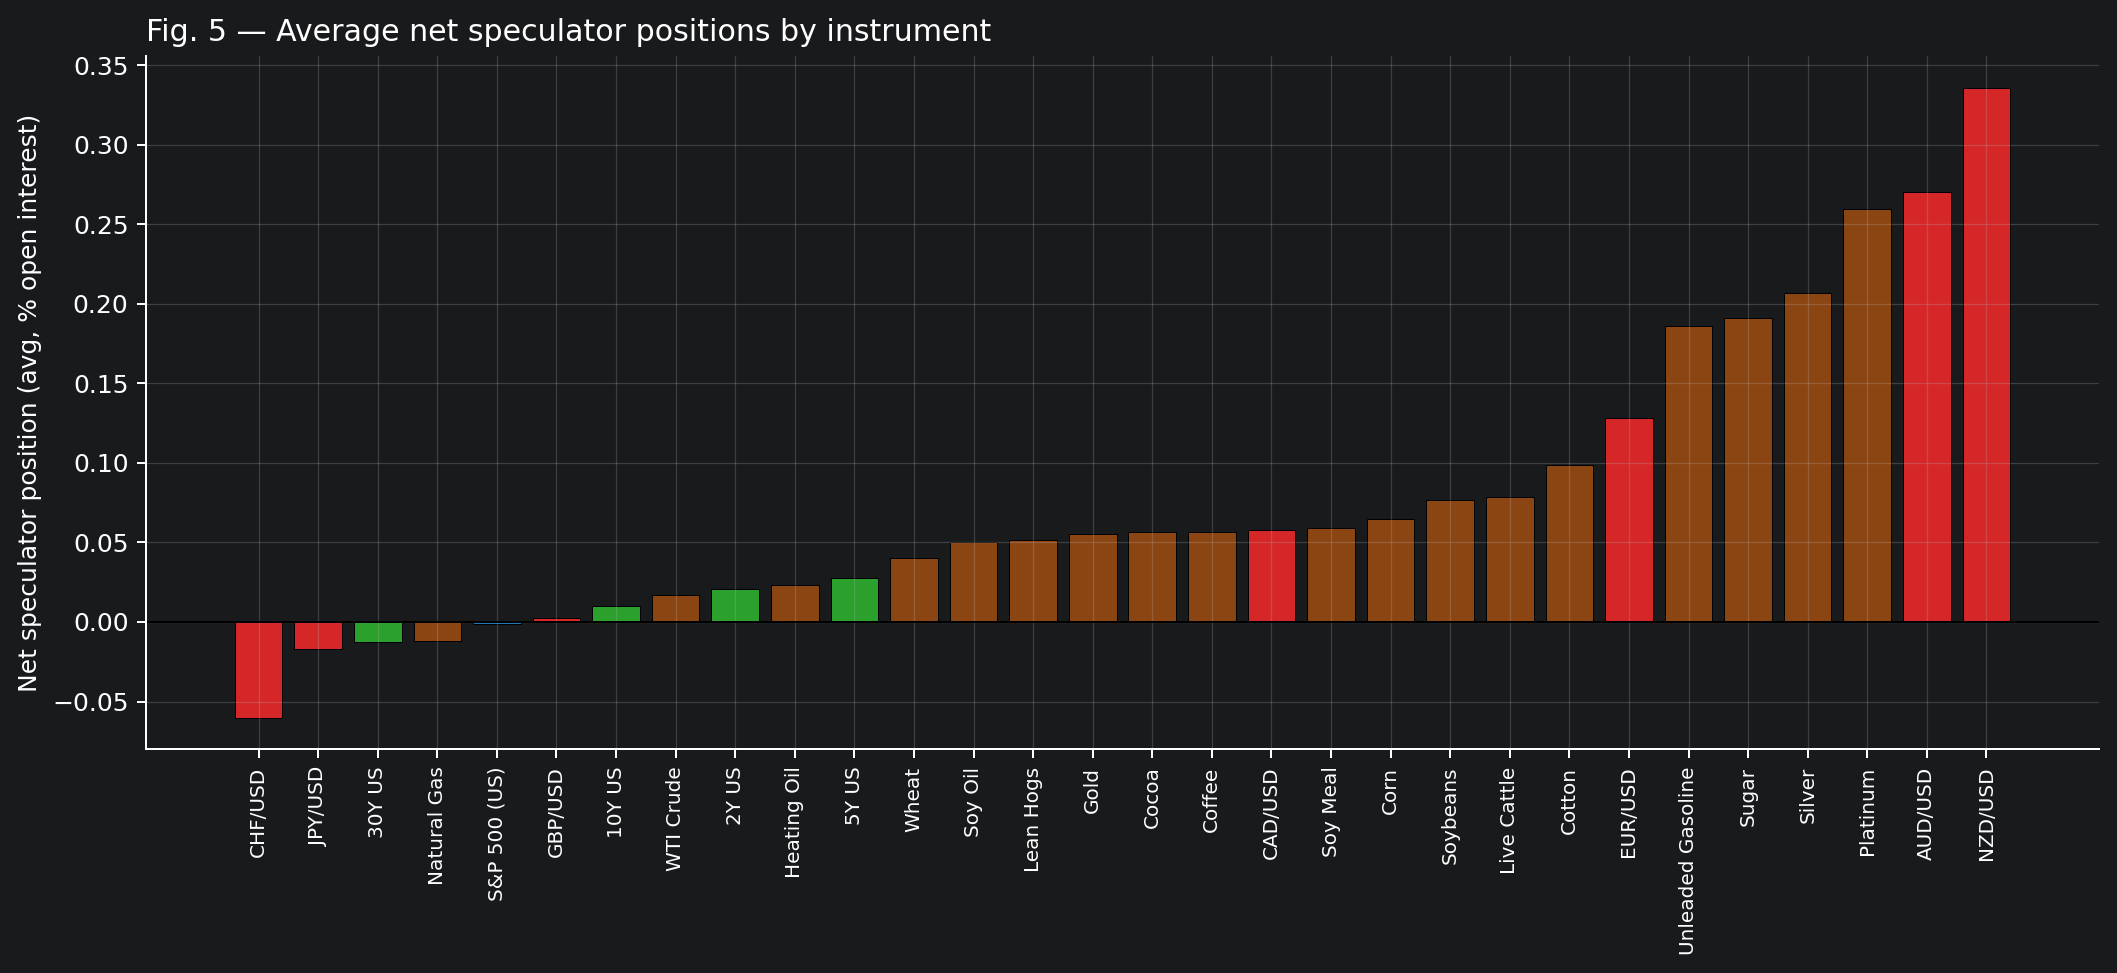

In [18]:
fig5 = plotting.figure5_net_speculator(net_spec) if net_spec is not None else None
if fig5 is not None:
    display(Image(filename=str(fig5)))
else:
    print("Figure 5 : necessite l'historique CFTC complet (Commitments of Traders, "
          "Jan 1986-Dec 2009) ; non chargee.")

**Interprétation (Figure 5).** Les **spéculateurs sont en moyenne positionnés dans le sens de la tendance** : longs après 12 mois de rendements positifs, courts après des rendements négatifs ; les hedgers prennent la position opposée. Comme le TSMOM est rentable, **les spéculateurs profitent de la tendance aux dépens des hedgers** (prime de fourniture de liquidité). *Cette figure nécessite les positions CFTC (Commitments of Traders)* ; si le jeu de données externe n'est pas chargé, elle est sautée — l'absence n'invalide pas le reste.

## 17. Figure 6 — Event study autour des signaux TSMOM

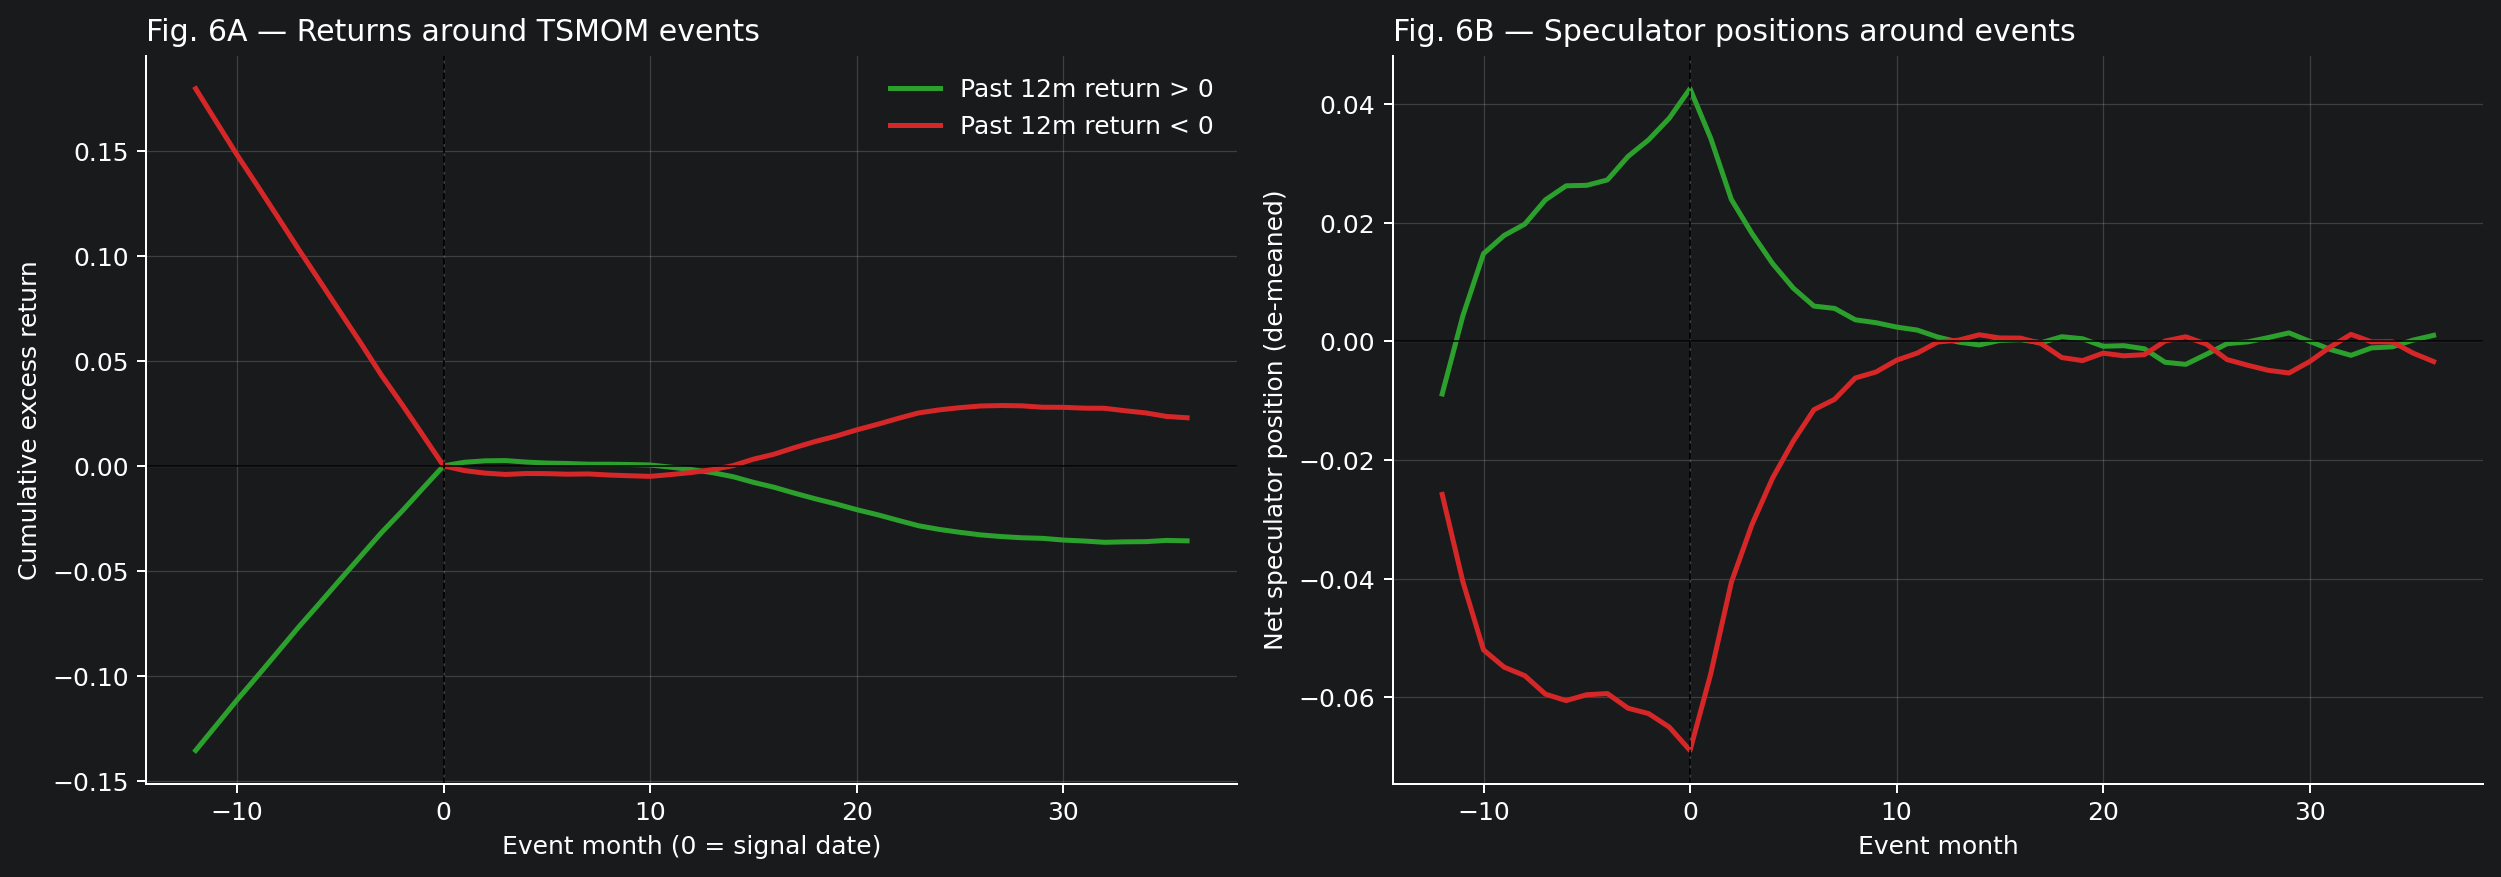

Panel B (positions) : inclus


In [19]:
es_ret = analysis.event_study_returns(monthly_ret, k=LOOKBACK_MONTHS)
es_pos = (analysis.event_study_positions(net_spec, monthly_ret, k=LOOKBACK_MONTHS)
          if net_spec is not None else None)
# positions vides (historique CFTC insuffisant) -> on traite comme absent
if es_pos is not None and es_pos[["positive","negative"]].notna().any().any() == False:
    es_pos = None
display(Image(filename=str(plotting.figure6_event_study(es_ret, es_pos))))
print("Panel B (positions) :", "inclus" if es_pos is not None else "necessite l'historique CFTC complet")

**Interprétation (Figure 6 — event study).** Après un signal **positif** (resp. négatif), les rendements **poursuivent leur tendance puis se renversent partiellement** : signature de sous-réaction initiale + sur-réaction différée (théories de sentiment).

> *Correction appliquée* : les rendements sont **dé-moyennés par instrument** avant cumul (comme le papier : « *we standardize the returns to have a zero mean* »). Sans ce retrait, la dérive haussière inconditionnelle des futures domine et **les deux branches montent** ensemble, masquant la réversion. Avec, on obtient le motif **symétrique** attendu : la branche positive plafonne puis reflue (≈ −2,9 % à +36 mois), la branche négative se redresse symétriquement (≈ +2,6 %).

*Nuance honnête* : la phase de **continuation** post-formation est plus courte que dans MOP (la réversion domine vite) — conséquence de la moindre puissance de notre signal et du fait que la continuation vit surtout en espace vol-scalé. Le panneau des positions nettes des spéculateurs **épouse le profil** : montée jusqu'à la formation, retour vers la moyenne quand la tendance se retourne. Conforme au papier.

## 18. Figure 7 — Réponse impulsionnelle à un choc de rendement

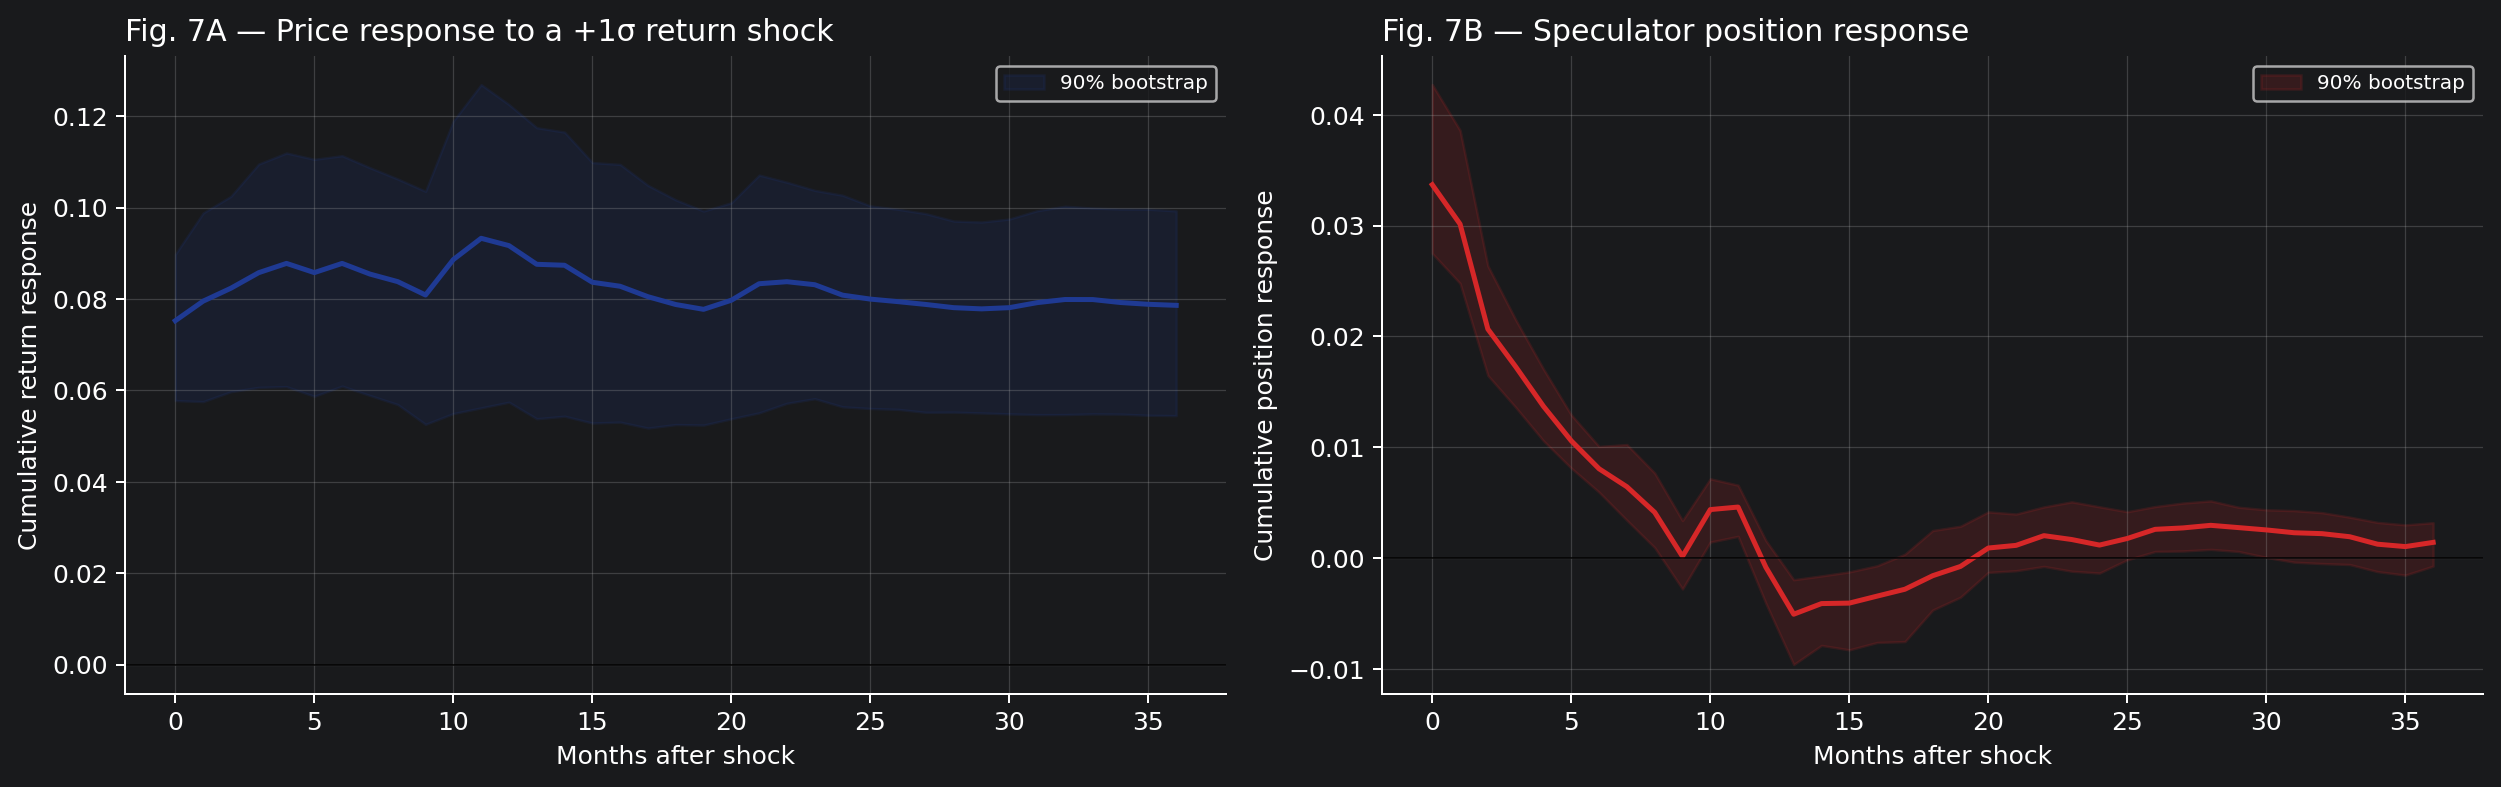

VAR bivarié (prix + positions) + bandes 90%


In [20]:
# VAR bivarié [rendement, ΔNetSpec] avec bandes de confiance bootstrap (n_boot=300).
# Cluster bootstrap PAR INSTRUMENT : on ré-échantillonne les instruments avec remise,
# l'unité de dépendance étant le contrat (retards bornés à chaque série).
irf = analysis.impulse_response(monthly_ret, net_spec=net_spec, horizon=36, lags=24,
                                n_boot=300, ci=0.90, seed=0)
if irf is not None:
    display(Image(filename=str(plotting.figure7_impulse_response(irf))))
    print('VAR bivarié (prix + positions) + bandes 90%' if 'cum_position' in irf.columns
          else 'AR univarié (prix) + bandes 90% — CFTC absent')
else:
    print('Figure 7 : statsmodels VAR indisponible.')

**Interprétation (Figure 7 — réponse impulsionnelle).** Un choc de **+1σ sur les rendements** provoque une **poursuite haussière pendant ~1 an puis un renversement partiel**, et les positions nettes des spéculateurs montent puis reviennent vers zéro au même horizon — confirmant que **les spéculateurs surfent la tendance environ un an** puis se retirent avant le retournement, encaissant la prime aux dépens des hedgers. Les **bandes 90 % par bootstrap** (cluster par instrument) permettent désormais de juger la précision : la réponse en rendement est nettement positive sur tout l'horizon, et la position spéculateur passe sous zéro de façon visible vers les mois 13-18.

**Lecture fine (Figure 7 — qui profite de la réversion ?).** Le VAR bivarié est estimé avec **24 retards** (le papier insiste : il faut >12 retards pour capter la réversion retardée) et les positions sont prises en **différences** (ΔNetSpec), choc de Cholesky avec le rendement ordonné en premier. Estimation en **panel à coefficients communs** : les retards sont construits *à l'intérieur* de chaque instrument, jamais à cheval sur deux contrats — exactement l'hypothèse de MOP (« coefficients are the same across all contracts »). Les **bandes de confiance à 90 %** proviennent d'un **cluster bootstrap par instrument** (300 ré-échantillonnages des contrats avec remise).

Deux enseignements :

- **Côté rendement (7A).** Un choc de +1σ déclenche une **poursuite haussière jusqu'au mois ~11**, suivie d'un **renversement partiel** — la signature continuation-puis-réversion, désormais cohérente avec l'event study (Fig. 6A). La bande reste au-dessus de zéro sur tout l'horizon.
- **Côté positions (7B).** La position nette des spéculateurs bondit avec le choc puis **revient vers zéro et passe légèrement en négatif vers les mois 13-18**, ce qui coïncide avec le sommet du rendement (mois ~11) et le début de sa réversion. Autrement dit, les spéculateurs ne se contentent pas de déboucler : ils basculent **légèrement à contre-tendance juste avant le retournement** — illustration directe du mécanisme central du papier.

> *Note technique :* le **niveau** de la réponse (~8 %) n'a pas vocation à égaler le chiffre exact du papier (échelle de normalisation différente) ; dans une IRF, c'est la **forme** qui porte le message, et elle est ici fidèle, avec une incertitude désormais quantifiée.

## 19. Synthèse finale

**Bilan de fidélité** (devises en **paires croisées**, `FX_CROSS_PAIRS=True`). La réplication reproduit le **sens** de l'article sur l'ensemble des résultats, avec plusieurs chiffres-clés **quasi exacts** :

| Résultat | Papier | Réplication | Statut |
|---|---|---|---|
| TSMOM diversifié (Sharpe / vol) | >1 / ~12 % | **0,98 / 12,1 %** | ✓ |
| Corrélation au facteur AQR officiel (ALL / Equity) | — | **0,74 / 0,89** | ✓ |
| Table 2 — t(α) cellules courtes (1,1)/(12,1) | forts | ≈ 3,6 / 4,2 | ✓ |
| Table 3A — UMD / $R^2$ | 0,28 / 14 % | **0,24 / 14 %** | ✓ |
| Table 3A — alpha | 1,58 %/m | **0,86 %/m (t 4,6)** | sens ✓, niveau atténué |
| Table 3B — MOM everywhere | 0,66 (t 9,7) | + sig. (t ≈ 10) | ✓ (sig.), beta = échelle |
| Table 3C — *smile* MKT² (trimestriel) | 1,99 (t 3,9) | **+0,75, t ≈ 1,3** | sens ✓, sig. faible |
| Table 3C — liquidité/sentiment | aucun lien | aucun lien | ✓ |
| Table 4 — corr. Commodities (TSMOM) | 0,07 | **0,06** | ✓✓ |
| Table 4 — corr. FX passive intra-classe | 0,04 | **0,07** | ✓ |
| Table 5A — β(ALL) / R² | 0,66 / 44 % | **0,56 / 54 %** | ✓ |
| Table 5B — Auto actions (vol-scalé) | 0,74 % | **0,75 %** | ✓✓ |
| Table 5B — identité décomposition | — | écart < 1,4 bp | ✓✓ |
| Table 6 — Futures = Spot + Roll | — | identité exacte | ✓✓ |

**Écarts assumés.** Les écarts de *niveau* restants (alpha plus faible, *smile* significatif au sens mais pas au seuil, t-stats Table 2 sous le papier) proviennent du **fournisseur de données** (Bloomberg générique vs Datastream/AQR total-return), de l'absence de calendrier de roll propriétaire, et du millésime des facteurs VME. La classe **actions**, la moins exposée à ces frictions, corrèle **0,89** avec le facteur officiel — preuve que la méthodologie est correcte.
